# Sim Combinations - averaging together time series

For the {white, pink, brown} simulations, if you average together the time series, compute a power spectra and fit a spectral model, what is the resultant exponent? How does it relate to the simulated value(s)

### Imports

In [1]:
# Import required functionality

import numpy as np #Imports numpy and then shortens its name

from neurodsp.utils import create_times # this allows us to create a time axis for our signal
from neurodsp.sim import sim_powerlaw, sim_oscillation, sim_combined, set_random_seed # these allow us to simulate a time series
from neurodsp.spectral import compute_spectrum_welch # this allows us to compute power spectra
from neurodsp.plts import plot_time_series, plot_power_spectra # these allow us to plot time series and spectra

from specparam import SpectralModel #This allows us to initialise and fit spectral models
from specparam.plts import plot_spectra # Plot one or multiple power spectra

from matplotlib import pyplot

### Data Simulation settings

In [2]:
# Define simulation settings
n_seconds = 8
s_rate = 900

times = create_times(n_seconds, s_rate)
n_points = len(times)

### White, pink and brown noise - average time series


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

Aperiodic paramters: 
 [-1.06677197  2.22552653] 



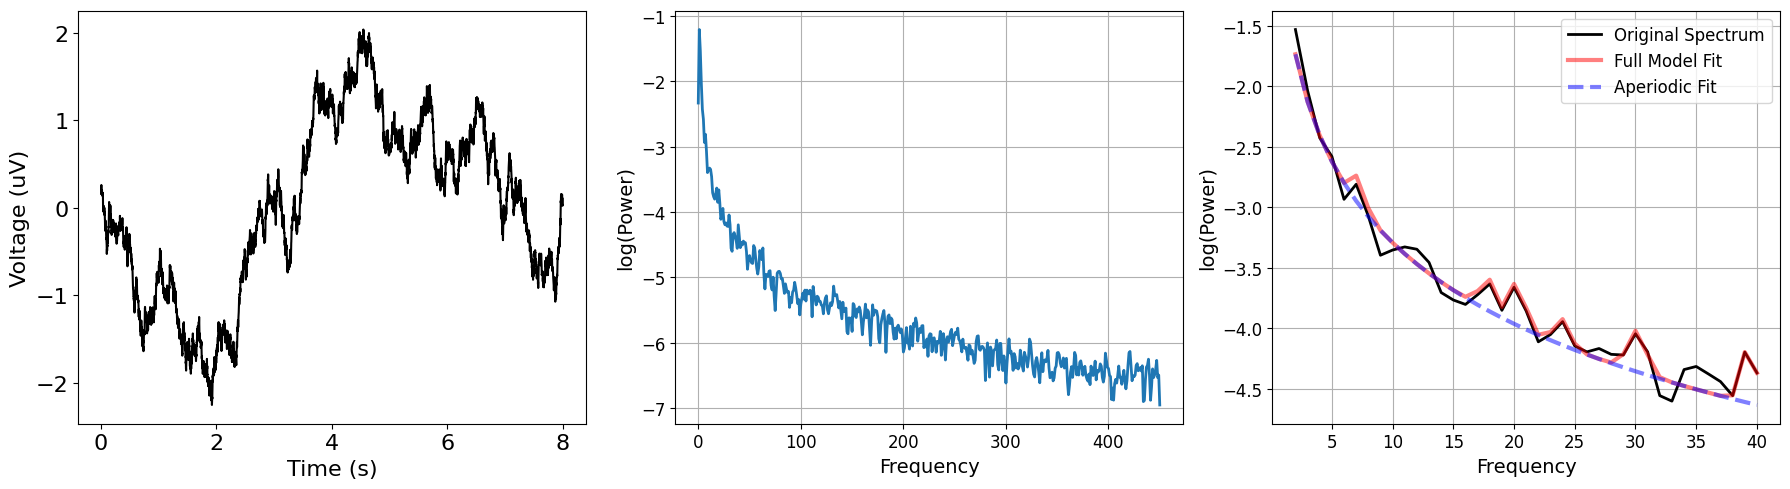

In [3]:
#Combining a signal containing the components of white, pink and brown noise
components = {
        'sim_powerlaw' : {'exponent' : 0},
    'sim_powerlaw' : {'exponent' : -1},
    'sim_powerlaw' : {'exponent' : -2},
}

sig = sim_combined(n_seconds, s_rate, components)

# Settings to plot figures horizontally
fig, (ax1, ax2, ax3) = pyplot.subplots(1, 3, figsize=(18,5))

# Plotting time series
plot_time_series(times, sig, ax=ax1)

# Computing and plotting the power spectra
freqs, powers = compute_spectrum_welch(sig, s_rate)
plot_spectra(freqs, powers, log_powers=True, ax=ax2)

# Initialising Spectral Model
fm = SpectralModel()

# Setting frequencing range
freq_range = [2, 40]

# Fitting and plotting model
fm.fit(freqs, powers, freq_range)
fm.plot(ax=ax3)

# Printing aperiodic offset and exponent
print ('Aperiodic paramters: \n', fm.results.params.aperiodic.params, '\n')

**Comments**
- Exponent most closely aligns with Brown Noise
- Visually also closely resemebles brown noise in shape
- However, it loses power in the higher frequencies less quickly. In earlier simulations, when looking at the PSD, the log power by 250Hz is between -6 and -7 however here it is between -5 and -6